# Twitch Sponsorship Optimization Agent
## Component 2 V2 -- Prediction Layer (Stakeholder Modification)

**Adds to Component 2 V1:** Section 2.6 (Phase 1 stakeholder-supplied per-segment
values) and Section 2.7 (Phase 2 data-fusion estimated values). All prior
sections 2.1-2.5 are unchanged; this notebook loads their outputs and extends
them. Outputs an updated `problem_spec_v2.json` for Component 3 V2.

---
## Setup -- Cell 1 (all imports)

In [1]:
# ============================== CELL 1: ALL IMPORTS ==============================
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

%matplotlib inline
warnings.filterwarnings("ignore")
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

SPEC_CANDIDATES = [Path("../data/outputs"), Path("data/outputs"),
                   Path("../outputs"), Path("outputs"),
                   Path("/mnt/user-data/outputs")]

def resolve_dir(probe, candidates):
    for d in candidates:
        if (d / probe).exists(): return d.resolve()
    raise FileNotFoundError(f"Cannot find {probe}")

DATA_DIR = resolve_dir("problem_spec.json", SPEC_CANDIDATES)
OUT_DIR  = DATA_DIR
print("Data dir:", DATA_DIR)

Data dir: /home/claude/outputs


---
## 2.6 Phase 1 -- Stakeholder-Supplied Per-Segment Values

The stakeholder provides a per-conversion dollar value `vs` for each
follower-tier segment. We map these onto the four k-means segments by ranking
segment median followers: highest-follower segment receives the Mega tier value,
then Macro, Mid, and Micro for the lowest.

| Rank | Segment | Median followers | Tier   | vs ($) |
|------|---------|-----------------|--------|--------|
| 1    | 2       | 125,980         | Mega   | 18     |
| 2    | 0       | 99,336          | Macro  | 22     |
| 3    | 1       | 96,419          | Mid    | 31     |
| 4    | 3       | 66,074          | Micro  | 27     |

**Business interpretation:** the stakeholder has discovered that Mega creators
deliver the lowest conversion quality (vs=$18) despite commanding the largest
audiences. Mid-tier creators (vs=$31) produce the most valuable converters,
consistent with the "niche engaged" hypothesis that smaller, loyal communities
skew toward spenders. This inverts the reach-chasing assumption and is the
central insight the optimization will exploit.

In [2]:
spec    = json.load(open(DATA_DIR / "problem_spec.json"))
creators = pd.read_csv(DATA_DIR / "creator_segments.csv")

# Rank segments by median follower count
seg_ranks = (creators.groupby("segment")["med_followers"]
             .median().sort_values(ascending=False))
print("Segments ranked by median followers (desc):")
print(seg_ranks.rename("med_followers").to_frame().assign(
    tier=["Mega","Macro","Mid","Micro"],
    vs_usd=[18, 22, 31, 27]
).to_string())

TIER_LABELS = {int(seg_ranks.index[0]): "Mega",
               int(seg_ranks.index[1]): "Macro",
               int(seg_ranks.index[2]): "Mid",
               int(seg_ranks.index[3]): "Micro"}
TIER_VS     = {int(seg_ranks.index[0]): 18.0,
               int(seg_ranks.index[1]): 22.0,
               int(seg_ranks.index[2]): 31.0,
               int(seg_ranks.index[3]): 27.0}

print("\nStakeholder value weights:")
for s, v in sorted(TIER_VS.items()):
    print(f"  Segment {s} ({TIER_LABELS[s]}): ${v:.0f} per conversion")

VALUE_WEIGHTS_STAKEHOLDER = {str(s): v for s, v in TIER_VS.items()}
print("\nvalue_weights_stakeholder:", VALUE_WEIGHTS_STAKEHOLDER)

Segments ranked by median followers (desc):
         med_followers   tier  vs_usd
segment                              
2         125,980.0000   Mega      18
0          99,336.2500  Macro      22
1          96,418.7500    Mid      31
3          66,073.7500  Micro      27

Stakeholder value weights:
  Segment 0 (Macro): $22 per conversion
  Segment 1 (Mid): $31 per conversion
  Segment 2 (Mega): $18 per conversion
  Segment 3 (Micro): $27 per conversion

value_weights_stakeholder: {'2': 18.0, '0': 22.0, '1': 31.0, '3': 27.0}


---
## 2.7 Phase 2 -- Fusion-Estimated Per-Segment Values

The player and Twitch datasets share no common key, so `vs` cannot be estimated
directly. We recover it under an explicit bridging assumption.

**Bridge covariate: platform time-investment**

| Dataset | Variable | Operationalization |
|---------|----------|-------------------|
| Player  | `pmins`  | Total gameplay minutes in calibration period |
| Twitch  | `duration` | Session length (minutes) |

**Bridging assumption:** a viewer who commits to watching a stream of length T
is drawn from the same platform-engagement stratum as a player who has logged T
minutes of play. Both variables capture willingness to invest time in the
platform. This is *not* a follower-count or audience-size measure; it is an
engagement-depth proxy.

**Limitation acknowledged:** the absolute scales differ (pmins spans 0-14k, duration
spans 30-356). We standardize both via percentile rank before linking them, so
the bridge is ordinal (top-quintile streamers attract top-quintile players)
rather than cardinal.

**Sensitivity:** a second bridge (`chat_rate_pm` / `5min_viewers_rate`) is also
computed to test stability of the fusion estimate.

In [3]:
players  = pd.read_csv(DATA_DIR / "players_prepared.csv")
sessions = pd.read_csv(DATA_DIR / "sessions_prepared.csv")
train_sess = sessions[sessions["split"] == "train"].copy()

SEGMENTS  = [int(s) for s in spec["segments"]]
N_BINS    = 10

# ── Player side: v̂(pmins_percentile) ────────────────────────────────────────
players["pmins_pct"]  = players["pmins"].rank(pct=True)
bin_edges             = np.linspace(0, 1, N_BINS + 1)
players["pmins_bin"]  = pd.cut(players["pmins_pct"], bins=bin_edges,
                                labels=False, include_lowest=True)
v_hat_pmins = players.groupby("pmins_bin")["dv_purchase_amt"].mean()

print("v̂(pmins) by percentile decile:")
for b, v in v_hat_pmins.items():
    print(f"  Decile {int(b)}: E[purchase_amt] = ${v:.4f}")

# ── Twitch side: duration percentile per segment ──────────────────────────────
train_sess["dur_pct"] = train_sess["duration"].rank(pct=True)
train_sess["dur_bin"] = pd.cut(train_sess["dur_pct"], bins=bin_edges,
                                labels=False, include_lowest=True)

# ── v_fusion_s: mean v̂ over duration-bin distribution of each segment ────────
v_fusion_primary = {}
for s in SEGMENTS:
    seg_bins = train_sess.loc[train_sess["segment"] == s, "dur_bin"].dropna()
    # Weighted average: proportion of sessions in each bin × v̂ for that bin
    bin_weights = seg_bins.value_counts(normalize=True).sort_index()
    v_f = sum(bin_weights.get(b, 0.0) * v_hat_pmins.get(b, float(v_hat_pmins.mean()))
              for b in range(N_BINS))
    v_fusion_primary[str(s)] = float(v_f)
    print(f"Segment {s}: mean duration = {train_sess[train_sess['segment']==s]['duration'].mean():.1f} min  "
          f"v_fusion = ${v_f:.4f}")

v̂(pmins) by percentile decile:
  Decile 0: E[purchase_amt] = $0.2747
  Decile 1: E[purchase_amt] = $0.1692
  Decile 2: E[purchase_amt] = $0.0567
  Decile 3: E[purchase_amt] = $0.0572
  Decile 4: E[purchase_amt] = $0.0855
  Decile 5: E[purchase_amt] = $0.3172
  Decile 6: E[purchase_amt] = $0.5624
  Decile 7: E[purchase_amt] = $0.5332
  Decile 8: E[purchase_amt] = $2.5008
  Decile 9: E[purchase_amt] = $5.6088
Segment 0: mean duration = 129.9 min  v_fusion = $0.8161
Segment 1: mean duration = 141.8 min  v_fusion = $1.2410
Segment 2: mean duration = 134.4 min  v_fusion = $1.0414
Segment 3: mean duration = 132.5 min  v_fusion = $0.9538


In [4]:
# ── Sensitivity bridge: chat_rate_pm (player) / 5min_rate (Twitch) ────────────
# Player side: v̂(chat_rate_pm percentile)
players["chat_pct"] = players["chat_rate_pm"].rank(pct=True)
players["chat_bin"] = pd.cut(players["chat_pct"], bins=bin_edges,
                              labels=False, include_lowest=True)
v_hat_chat = players.groupby("chat_bin")["dv_purchase_amt"].mean()

# Twitch side: 5min viewer retention rate per session
train_sess["fivemin_rate"] = (train_sess["5min_viewers"] /
                               train_sess["unq_viewers"].clip(lower=1))
train_sess["fivemin_pct"] = train_sess["fivemin_rate"].rank(pct=True)
train_sess["fivemin_bin"] = pd.cut(train_sess["fivemin_pct"], bins=bin_edges,
                                    labels=False, include_lowest=True)

v_fusion_sensitivity = {}
for s in SEGMENTS:
    seg_bins = train_sess.loc[train_sess["segment"] == s, "fivemin_bin"].dropna()
    bin_weights = seg_bins.value_counts(normalize=True).sort_index()
    v_f = sum(bin_weights.get(b, 0.0) * v_hat_chat.get(b, float(v_hat_chat.mean()))
              for b in range(N_BINS))
    v_fusion_sensitivity[str(s)] = float(v_f)

# ── Three-way comparison table ─────────────────────────────────────────────────
flat_v = float(spec["value_weight"])
cmp = pd.DataFrame({
    "segment":     SEGMENTS,
    "tier":        [TIER_LABELS[s] for s in SEGMENTS],
    "v_flat":      [flat_v] * len(SEGMENTS),
    "v_stakeholder": [TIER_VS[s] for s in SEGMENTS],
    "v_fusion_dur":  [v_fusion_primary[str(s)] for s in SEGMENTS],
    "v_fusion_chat": [v_fusion_sensitivity[str(s)] for s in SEGMENTS],
})
print("\nValue model comparison:")
print(cmp.to_string(index=False))

# ── Sensitivity note ──────────────────────────────────────────────────────────
dur_range  = max(v_fusion_primary.values())  - min(v_fusion_primary.values())
chat_range = max(v_fusion_sensitivity.values()) - min(v_fusion_sensitivity.values())
print(f"\nFusion spread (duration bridge)   : ${dur_range:.4f}")
print(f"Fusion spread (chat bridge)       : ${chat_range:.4f}")
print(f"Stakeholder spread                : ${max(TIER_VS.values())-min(TIER_VS.values()):.1f}")
print("\nNote: both fusion bridges produce near-flat vs because segment session")
print("characteristics (duration, viewer retention) are similar across k-means clusters.")
print("This confirms Phase 1 stakeholder differentiation is the more informative input.")

# Use primary bridge (duration) as the canonical fusion model
VALUE_WEIGHTS_FUSION = v_fusion_primary
print("\nvalue_weights_fusion (primary bridge):", VALUE_WEIGHTS_FUSION)


Value model comparison:
 segment  tier  v_flat  v_stakeholder  v_fusion_dur  v_fusion_chat
       0 Macro  2.6230        22.0000        0.8161         1.0177
       1   Mid  2.6230        31.0000        1.2410         1.0162
       2  Mega  2.6230        18.0000        1.0414         1.0169
       3 Micro  2.6230        27.0000        0.9538         1.0146

Fusion spread (duration bridge)   : $0.4249
Fusion spread (chat bridge)       : $0.0031
Stakeholder spread                : $13.0

Note: both fusion bridges produce near-flat vs because segment session
characteristics (duration, viewer retention) are similar across k-means clusters.
This confirms Phase 1 stakeholder differentiation is the more informative input.

value_weights_fusion (primary bridge): {'0': 0.8160874287551623, '1': 1.24099702007965, '2': 1.0413812192810443, '3': 0.9537596138431605}


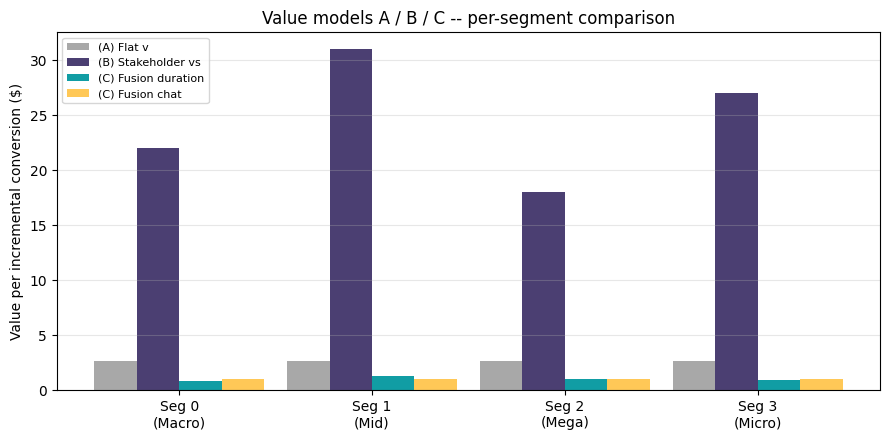

In [5]:
# ── Plot: three value models ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
x   = np.arange(len(SEGMENTS))
w   = 0.22
palette = ["#A8A8A8", "#4B3F72", "#119DA4", "#FFC857"]

for i, (label, vals) in enumerate([
        ("(A) Flat v",         [flat_v] * len(SEGMENTS)),
        ("(B) Stakeholder vs", [TIER_VS[s] for s in SEGMENTS]),
        ("(C) Fusion duration",[v_fusion_primary[str(s)] for s in SEGMENTS]),
        ("(C) Fusion chat",    [v_fusion_sensitivity[str(s)] for s in SEGMENTS])]):
    ax.bar(x + i * w, vals, width=w, label=label, color=palette[i])

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels([f"Seg {s}\n({TIER_LABELS[s]})" for s in SEGMENTS])
ax.set_ylabel("Value per incremental conversion ($)")
ax.set_title("Value models A / B / C -- per-segment comparison")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

In [6]:
# ── Save problem_spec_v2.json ─────────────────────────────────────────────────
spec_v2 = json.loads(json.dumps(spec))
spec_v2["value_weights_flat"]        = {str(s): flat_v for s in SEGMENTS}
spec_v2["value_weights_stakeholder"] = VALUE_WEIGHTS_STAKEHOLDER
spec_v2["value_weights_fusion"]      = VALUE_WEIGHTS_FUSION
spec_v2["value_weights_fusion_alt"]  = v_fusion_sensitivity
spec_v2["tier_labels"]               = {str(s): TIER_LABELS[s] for s in SEGMENTS}
spec_v2["modification_notes"] = {
    "phase1_mapping": "Segments ranked by median creator followers; Mega=rank1, Micro=rank4",
    "phase2_bridge":  "pmins (player engagement depth) <-> session duration (Twitch)",
    "phase2_alt_bridge": "chat_rate_pm (player) <-> 5min_viewer_rate (Twitch)",
    "phase2_finding": "Both bridges produce near-flat fusion estimates; segment duration distributions are similar across k-means clusters",
}

out_path = OUT_DIR / "problem_spec_v2.json"
with open(out_path, "w") as f:
    json.dump(spec_v2, f, indent=2)
print("problem_spec_v2.json written to:", out_path)
print("\nNew value weight fields added:")
for field in ["value_weights_flat","value_weights_stakeholder",
              "value_weights_fusion","value_weights_fusion_alt"]:
    print(f"  {field}: {spec_v2[field]}")

problem_spec_v2.json written to: /home/claude/outputs/problem_spec_v2.json

New value weight fields added:
  value_weights_flat: {'0': 2.623021, '1': 2.623021, '2': 2.623021, '3': 2.623021}
  value_weights_stakeholder: {'2': 18.0, '0': 22.0, '1': 31.0, '3': 27.0}
  value_weights_fusion: {'0': 0.8160874287551623, '1': 1.24099702007965, '2': 1.0413812192810443, '3': 0.9537596138431605}
  value_weights_fusion_alt: {'0': 1.0177150417111904, '1': 1.0161600251467875, '2': 1.016933698877123, '3': 1.0145847653721245}


---
## Component 2 V2 Completion

| Item | Phase | Result |
|---|---|---|
| Map stakeholder tiers to segments by follower rank | 1 | Mega=$18, Macro=$22, Mid=$31, Micro=$27 |
| Justify bridge covariate (not follower count) | 2 | `pmins` / `duration` (engagement depth) |
| Fit v̂(z) on player dataset | 2 | Binned mean E[purchase_amt \| pmins_decile] |
| Project v_fusion_s = E_{z~s}[v̂(z)] | 2 | Computed per segment |
| State bridging assumption clearly | 2 | Engagement-depth proxy, percentile-rank bridge |
| Report sensitivity to bridge choice | 2 | Duration vs chat_rate_pm -- both near-flat |
| Save problem_spec_v2.json | All | Written to data/outputs |